In [53]:
%pip install yfinance pandas-datareader tensorflow scikit-learn plotly -q

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline


In [55]:
import yfinance as yf
import datetime as dt
start = dt.datetime(2010,1,1)
end = dt.datetime(2019,12,31)
stock="AAPL"
df = yf.download(stock, start, end)


[*********************100%***********************]  1 of 1 completed


In [56]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.400960,6.415616,6.352207,6.383612,493729600
2010-01-05,6.412025,6.448216,6.378227,6.418606,601904800
2010-01-06,6.310034,6.437449,6.303454,6.412026,552160000
2010-01-07,6.298370,6.340842,6.252608,6.333365,477131200
2010-01-08,6.340242,6.340841,6.252907,6.289994,447610800


In [57]:
df.shape
print(df.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2010-01-04 to 2019-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2515 non-null   float64
 1   (High, AAPL)    2515 non-null   float64
 2   (Low, AAPL)     2515 non-null   float64
 3   (Open, AAPL)    2515 non-null   float64
 4   (Volume, AAPL)  2515 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


In [59]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [60]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,25.021567,25.237219,24.789576,25.015257,2.996722e+08
std,13.837168,13.939151,13.715254,13.817904,2.352933e+08
min,5.744145,5.862287,5.690308,5.753715,4.544800e+07
25%,13.742691,13.886265,13.628915,13.775646,1.247618e+08
50%,22.174234,22.343738,21.978828,22.143409,2.220316e+08
75%,35.052296,35.459411,34.730322,35.119960,4.068050e+08
max,70.146828,70.736363,69.328709,70.050582,1.880998e+09


In [61]:
df=df.reset_index()
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

In [62]:
df.to_csv("AAPL.csv")

In [63]:
d1=pd.read_csv("AAPL.csv")

In [64]:
d1.head()

,Unnamed: 0,Date,Close,High,Low,Open,Volume
0,0,2010-01-04,6.400960,6.415616,6.352207,6.383612,493729600
1,1,2010-01-05,6.412025,6.448216,6.378227,6.418606,601904800
2,2,2010-01-06,6.310034,6.437449,6.303454,6.412026,552160000
3,3,2010-01-07,6.298370,6.340842,6.252608,6.333365,477131200
4,4,2010-01-08,6.340242,6.340841,6.252907,6.289994,447610800


In [65]:
#Candlesticks
import plotly.graph_objects as go
fig = go.Figure(data=[go.Candlestick(x=df['Date'],
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()


In [66]:
df=df.drop(['Date'],axis=1)

In [67]:
df.head()

,Close,High,Low,Open,Volume
0,6.400960,6.415616,6.352207,6.383612,493729600
1,6.412025,6.448216,6.378227,6.418606,601904800
2,6.310034,6.437449,6.303454,6.412026,552160000
3,6.298370,6.340842,6.252608,6.333365,477131200
4,6.340242,6.340841,6.252907,6.289994,447610800


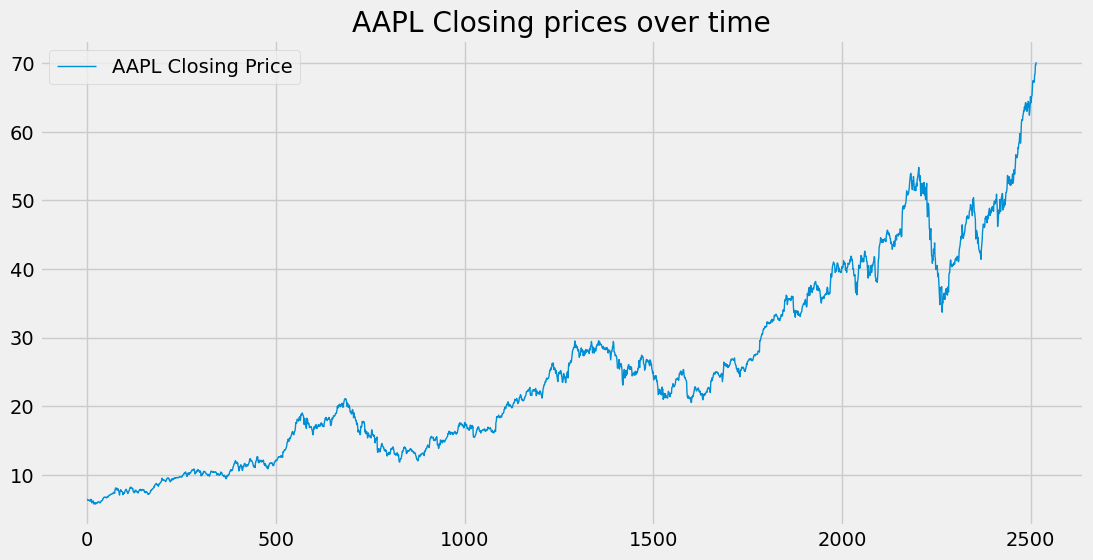

In [68]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f'{stock} Closing prices over time')
plt.legend()
plt.show()

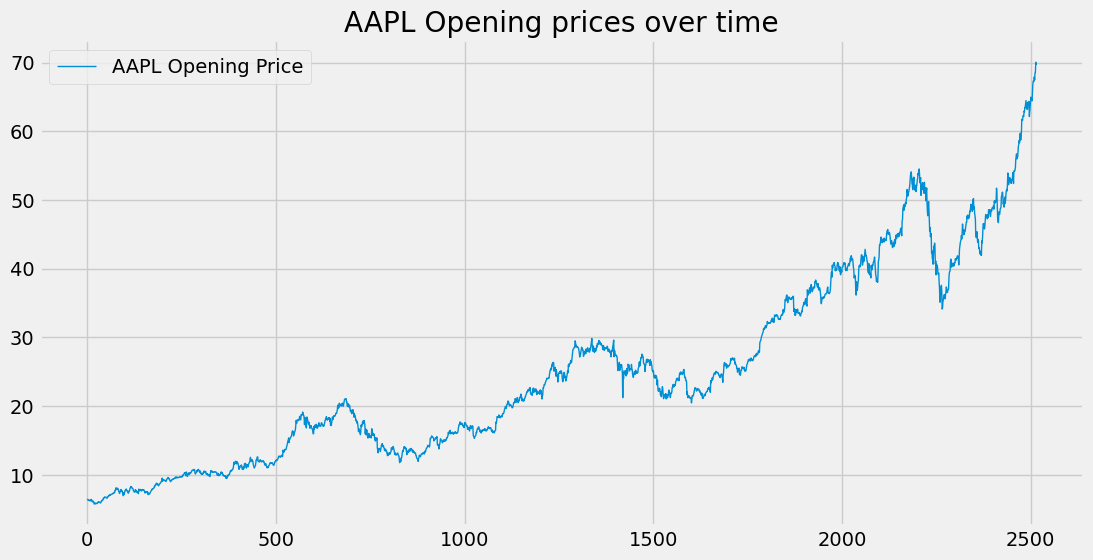

In [69]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 1)
plt.title(f'{stock} Opening prices over time')
plt.legend()
plt.show()

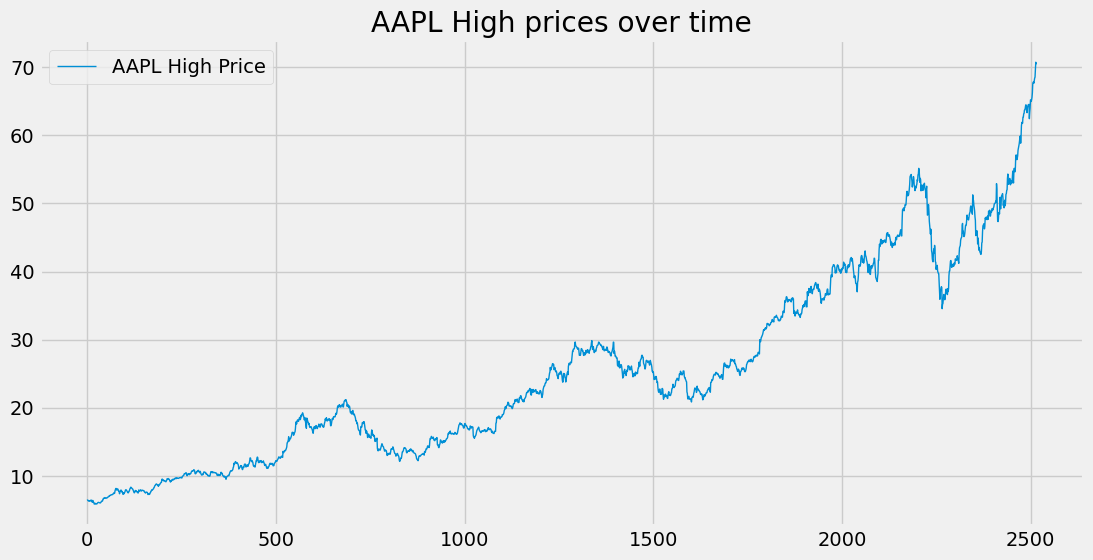

In [70]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 1)
plt.title(f'{stock} High prices over time')
plt.legend()
plt.show()

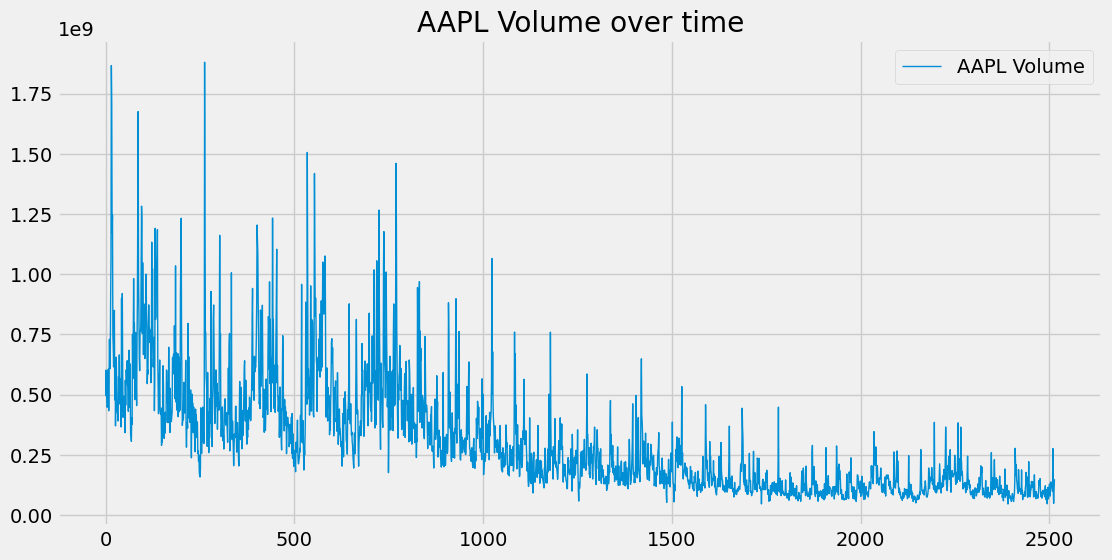

In [71]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume', linewidth = 1)
plt.title(f'{stock} Volume over time')
plt.legend()
plt.show()

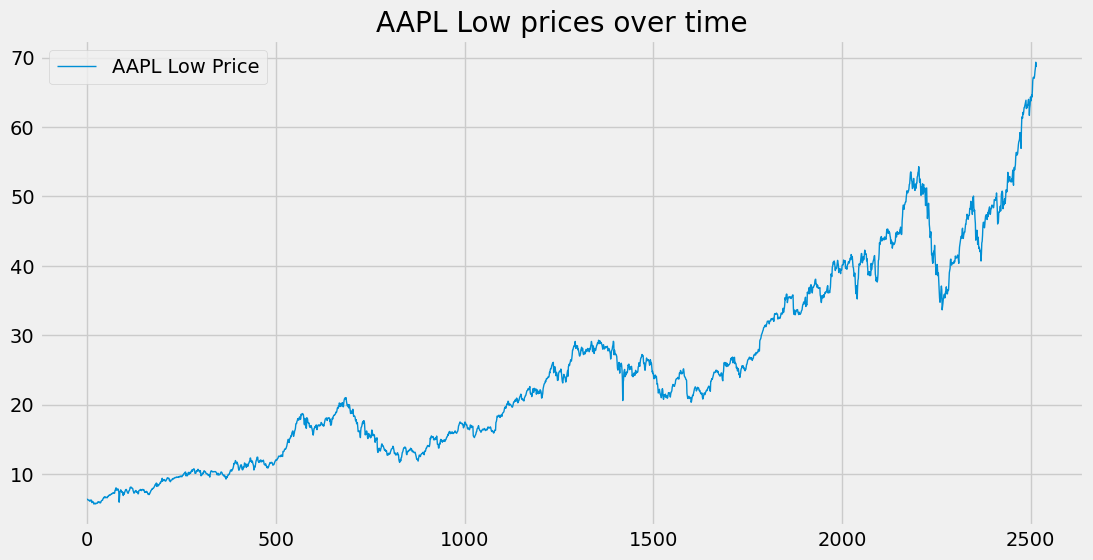

In [72]:
plt.figure(figsize=(12, 6))
plt.plot(df['Low'], label = f'{stock} Low Price', linewidth = 1)
plt.title(f'{stock} Low prices over time')
plt.legend()
plt.show()

In [73]:
#Moving average
ma100 = df.Close.rolling(100).mean()
ma100

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
2510    56.863087
2511    57.059510
2512    57.295029
2513    57.521537
2514    57.747307
Name: Close, Length: 2515, dtype: float64

In [74]:
ma200 = df.Close.rolling(200).mean()
ma200

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
2510    51.845575
2511    51.972232
2512    52.104722
2513    52.234675
2514    52.363853
Name: Close, Length: 2515, dtype: float64

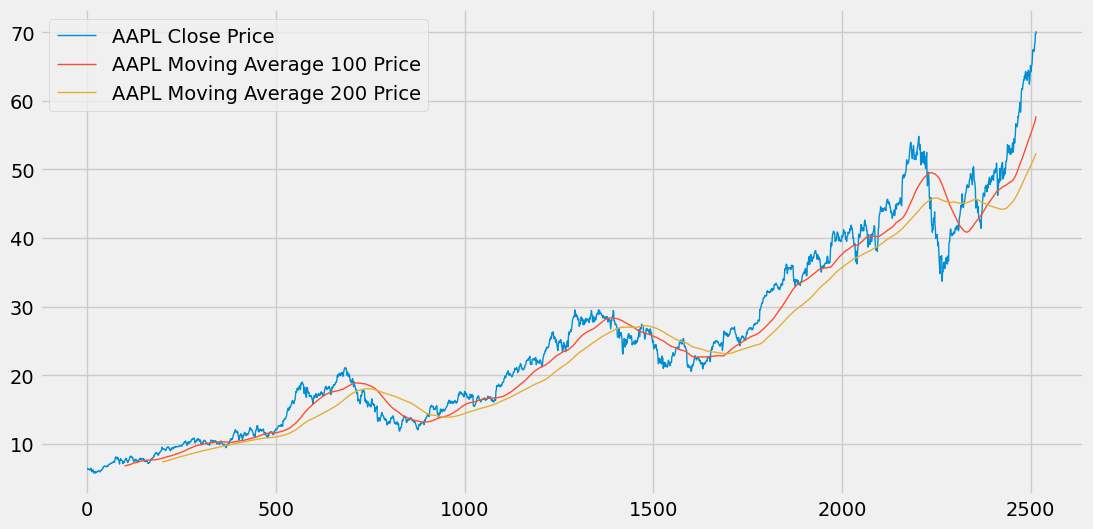

In [75]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ma100, label = f'{stock} Moving Average 100 Price', linewidth = 1)
plt.plot(ma200, label = f'{stock} Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [76]:
# Exopential moving averages
ema100 = df['Close'].ewm(span=100, adjust = False).mean()
ema200 = df['Close'].ewm(span=200, adjust = False).mean()

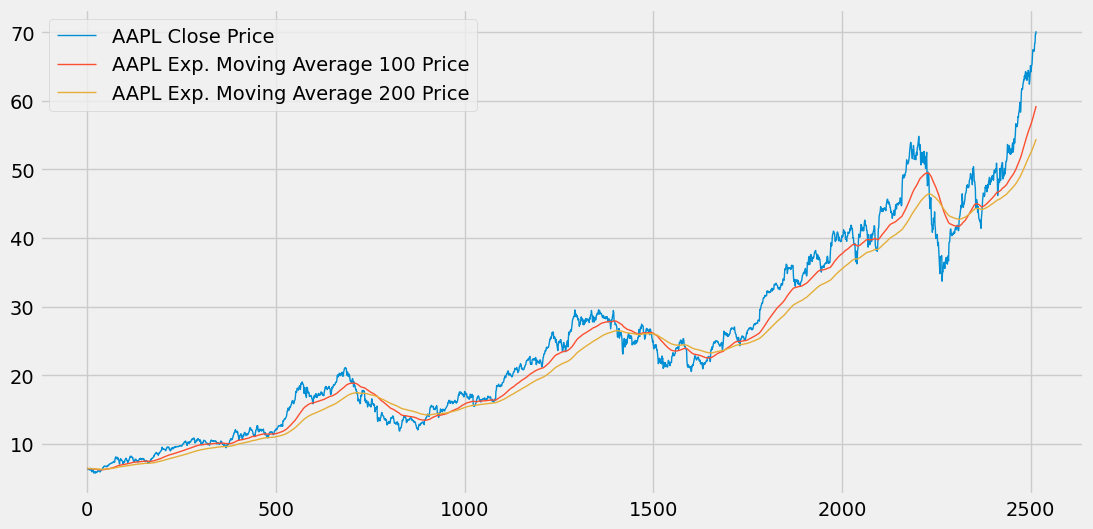

In [77]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ema100, label = f'{stock} Exp. Moving Average 100 Price', linewidth = 1)
plt.plot(ema200, label = f'{stock} Exp. Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [78]:
# Training & testing
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [79]:
data_training.shape
data_testing.shape

(755, 1)

In [80]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (0, 1))
data_training_array = scaler.fit_transform(data_training)

In [81]:
data_training_array.shape[0]

1760

In [82]:
x_train=[]
y_train=[]

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])
x_train,y_train=np.array(x_train),np.array(x_train)

In [83]:
#Model Building
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [84]:
model=Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

c:\Users\anann\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [85]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0570
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0155
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0150
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0131
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0112
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0114
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 0.0099
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0111
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0098
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0104
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0095
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0088
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0083
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - loss: 0.0086
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - loss: 0

In [89]:
past_100_days = data_training.tail(100)
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [90]:
input_data = scaler.fit_transform(final_df)

In [91]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test  = np.array(x_test), np.array(y_test)

In [92]:
y_pred=model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step


In [93]:
scaler.scale_

array([0.02147652])

In [94]:
scaler_factor=1/0.0035166
y_pred=y_pred*scaler_factor
y_test=y_test*scaler_factor

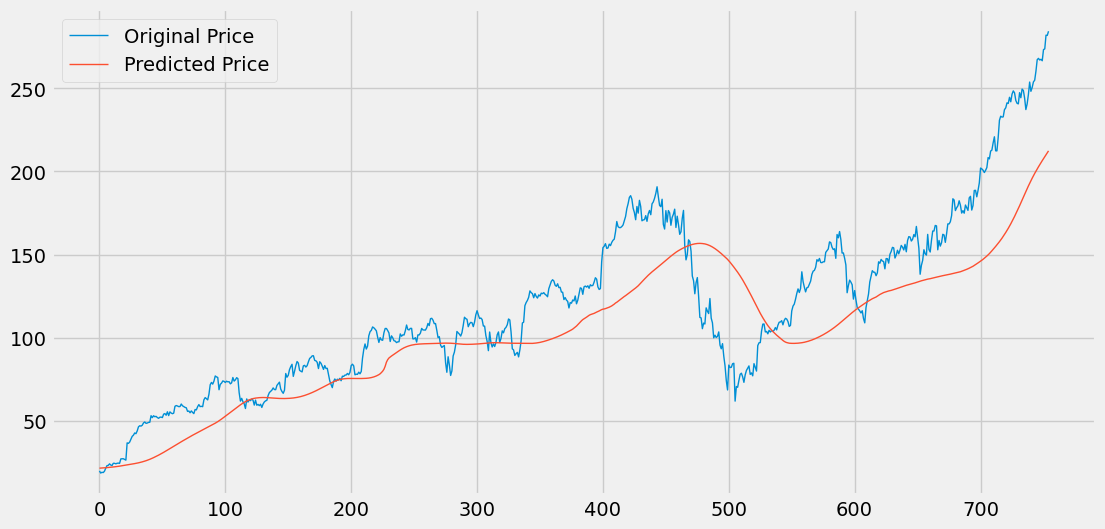

In [96]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label = 'Original Price', linewidth = 1)
plt.plot(y_pred, label = 'Predicted Price', linewidth = 1)
plt.legend()
plt.show()

In [99]:
model.save('stock_dl_model.h5')